# Mixed-layer depth: Threshold vs. Depth Integration Method

This notebook compares the two mixed-layer-depth (MLD) estimators implemented in
`dbof.preprocessing.calculated_fields_at_depth`:

1. **Threshold MLD** (`mixed_layer_depth`, the project default) — the deepest
   depth where the potential density anomaly $\sigma_0$ exceeds its value at the
   10 m reference level by $\le 0.03\;\mathrm{kg\,m^{-3}}$ (Bodner et al.).
   $$\mathrm{MLD} = {\rm Depth \, where}: \;\; \sigma_0(z) - \sigma_0(10\,\rm m) \ge 0.03 \, \mathrm{kg\,m^{-3}}$$
2. **Depth Integration Method** (`mixed_layer_depth_DI`) — the $N^2$-weighted
   mean depth over the upper 300 m:
   $$\mathrm{MLD_{DI}} = \frac{\int_0^{300} z\,N^2(z)\,dz}{\int_0^{300} N^2(z)\,dz}.$$

We examine both on a few profiles drawn from the LLC4320 density tile
`density_tile359_20121109T12.nc`, which stores only $\sigma_0$ (potential
density anomaly, JMD95, $p=0$). The threshold estimator is reproduced here
directly from $\sigma_0$ — the same quantity `mixed_layer_depth` builds
internally from Theta/Salt — while `mixed_layer_depth_DI` is called from
production with $N^2$ derived from $\sigma_0$.

*Generated by JXP and Claude*

In [1]:
# Imports (all at the top, per project guidelines).
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import dbof.preprocessing.calculated_fields_at_depth as cfad
from dbof.preprocessing.vertical_helpers import (
    _vertical_derivative,
    _get_depth_coord,
    _nearest_k_to_depth,
)
from dbof.preprocessing.physical_constants import (
    G,
    RHO0_BOUSSINESQ,
    MLD_REFERENCE_DEPTH_M,
    MLD_INTEGRATION_DEPTH_M,
)

In [2]:
# Load the density tile (sigma0 only). Chunk vertically whole, tile in
# quarters so the reductions stay lazy (dask) until we materialise maps.
tile_path = os.path.join(
    os.environ['OS_OGCM'], 'LLC', 'Fronts', 'V4', '20121109_120000',
    'tiles', 'density_tile359_20121109T12.nc',
)
ds = xr.open_dataset(tile_path, chunks={'k': -1, 'j': 360, 'i': 360})

# The tile carries no layer-thickness variable (drF). Supply one on the
# integer-k axis from the cell-centre depths so _get_vertical_spacing does
# not fall back to a depth-valued coordinate (which would misalign with the
# integer-k N2). In production, ds_merge always carries drF.
z_pos = np.abs(ds['Z'].values).astype(float)   # positive-down depths [m]
ds['drF'] = (('k',), np.gradient(z_pos))        # approx layer thickness [m]
ds

<xarray.Dataset> Size: 114MB
Dimensions:       (k: 51, j: 720, i: 720)
Coordinates:
  * k             (k) int16 102B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * j             (j) int16 1kB 3600 3601 3602 3603 3604 ... 4316 4317 4318 4319
  * i             (i) int16 1kB 2160 2161 2162 2163 2164 ... 2876 2877 2878 2879
    face          int16 2B ...
    XC            (j, i) float64 4MB dask.array<chunksize=(360, 360), meta=np.ndarray>
    YC            (j, i) float64 4MB dask.array<chunksize=(360, 360), meta=np.ndarray>
    Z             (k) float64 408B dask.array<chunksize=(51,), meta=np.ndarray>
    tile_index    int64 8B ...
    face_index    int64 8B ...
    rect_i_start  int64 8B ...
    rect_j_start  int64 8B ...
Data variables:
    sigma0        (k, j, i) float32 106MB dask.array<chunksize=(51, 360, 360), meta=np.ndarray>
    drF           (k) float64 408B 1.07 1.145 1.307 1.495 ... 43.74 44.88 45.46
Attributes:
    timestamp:      2012-11-09 12:00:00
    iteration:      1463616
    tile_index:     359
    tile_j_rect:    14
    tile_i_rect:    23
    face_index:     10
    rect_i_user:    16590
    rect_j_user:    10350
    property:       density
    source_script:  dev/pot_density/generate_tile.py
    git_commit:     1ce78e3cbb6a598f0aa384d5bb2fa5c1f6d30b44

In [3]:
# Buoyancy frequency squared from sigma0: N^2 = (g/rho0) d(rho)/dz, where
# rho = sigma0 + 1000. _vertical_derivative uses the positive-down depth
# coordinate, so a stably stratified column gives N^2 > 0.
rho = ds['sigma0'] + 1000.0
n2 = (G / RHO0_BOUSSINESQ) * _vertical_derivative(rho, ds)
n2.name = 'N2'

# Positive-down depth coordinate (1D over k).
zdim = 'k'
z = _get_depth_coord(ds, zdim=zdim)
print('depth levels [m]:', np.round(z.values[:12], 2), '...')

depth levels [m]: [ 0.5   1.57  2.79  4.18  5.78  7.59  9.66 12.01 14.68 17.7  21.12 24.99] ...


In [4]:
# --- Threshold MLD (reproduces mixed_layer_depth on the supplied sigma0). ---
# Reference level: nearest model level to MLD_REFERENCE_DEPTH_M (10 m).
ref_k = _nearest_k_to_depth(z.values.astype(float), MLD_REFERENCE_DEPTH_M)
print(f'reference level k={ref_k} at z={float(z.values[ref_k]):.2f} m')

sigma0 = ds['sigma0']
delta_sigma = sigma0 - sigma0.isel({zdim: ref_k})
# Deepest depth where the density anomaly stays within the 0.03 threshold.
mld_thr = z.where(delta_sigma <= 0.03).max(dim=zdim)
mld_thr.name = 'MLD'

# --- Depth Integration MLD (production function, N2 supplied). ---
mld_di = cfad.mixed_layer_depth_DI(ds, n2=n2)

# Materialise both 2D fields once (single dask compute each).
mld_thr = mld_thr.compute()
mld_di = mld_di.compute()
print('MLD threshold : median %.1f m' % float(np.nanmedian(mld_thr)))
print('MLD_DI        : median %.1f m' % float(np.nanmedian(mld_di)))

reference level k=6 at z=9.66 m
MLD threshold : median 25.0 m
MLD_DI        : median 85.9 m


/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


## A few profiles

For each selected column we plot $\sigma_0(z)$ and $N^2(z)$ and overlay the two
MLD estimates. The threshold estimate lands on a discrete model level; the
Depth Integration estimate is a continuous, stratification-weighted depth.

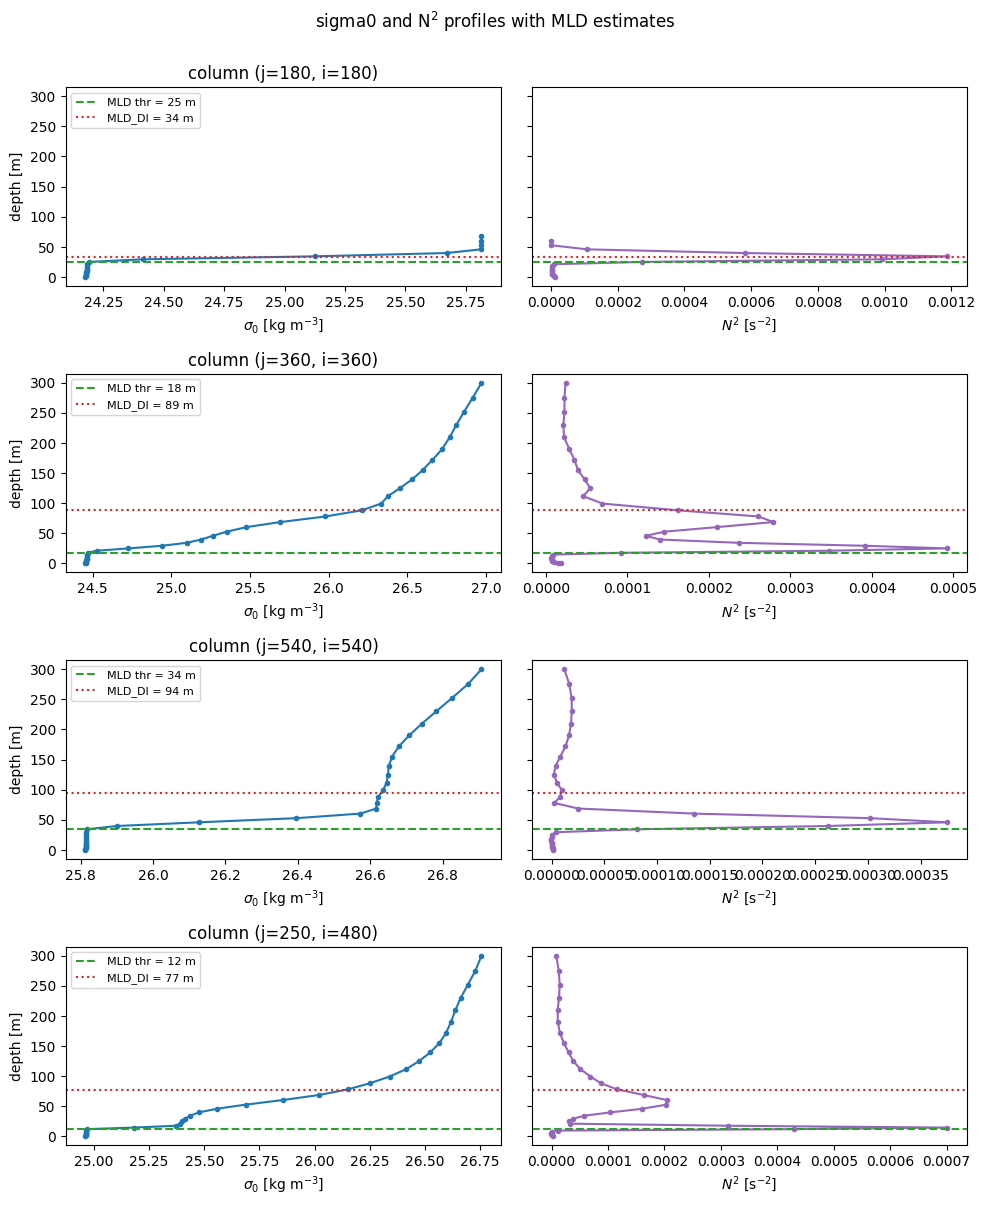

In [6]:
# Pick a few interior columns (avoid the fill-boundary edges of the tile).
profiles = [(180, 180), (360, 360), (540, 540), (250, 480)]
zmax = MLD_INTEGRATION_DEPTH_M   # limit plots to the upper 300 m
zv = z.values
in300 = zv <= zmax

fig, axes = plt.subplots(len(profiles), 2, figsize=(10, 3 * len(profiles)),
                         sharey=True)
for row, (jj, ii) in enumerate(profiles):
    s_prof = sigma0.isel(j=jj, i=ii).values
    n_prof = n2.isel(j=jj, i=ii).values
    m_thr = float(mld_thr.isel(j=jj, i=ii).values)
    m_di = float(mld_di.isel(j=jj, i=ii).values)

    # sigma0 profile.
    ax = axes[row, 0]
    ax.plot(s_prof[in300], zv[in300], '-o', ms=3, color='tab:blue')
    ax.axhline(m_thr, color='tab:green', ls='--',
               label=f'MLD thr = {m_thr:.0f} m')
    ax.axhline(m_di, color='tab:red', ls=':',
               label=f'MLD_DI = {m_di:.0f} m')
    ax.invert_yaxis()
    ax.set_ylabel('depth [m]')
    ax.set_xlabel(r'$\sigma_0$ [kg m$^{-3}$]')
    ax.set_title(f'column (j={jj}, i={ii})')
    ax.legend(fontsize=8, loc='upper left')

    # N^2 profile.
    ax = axes[row, 1]
    ax.plot(n_prof[in300], zv[in300], '-o', ms=3, color='tab:purple')
    ax.axhline(m_thr, color='tab:green', ls='--')
    ax.axhline(m_di, color='tab:red', ls=':')
    ax.set_xlabel(r'$N^2$ [s$^{-2}$]')

fig.suptitle('sigma0 and N$^2$ profiles with MLD estimates', y=1.001)
fig.tight_layout()
plt.show()

## Tile-wide comparison

Side-by-side maps of the two estimators and a histogram of their difference.

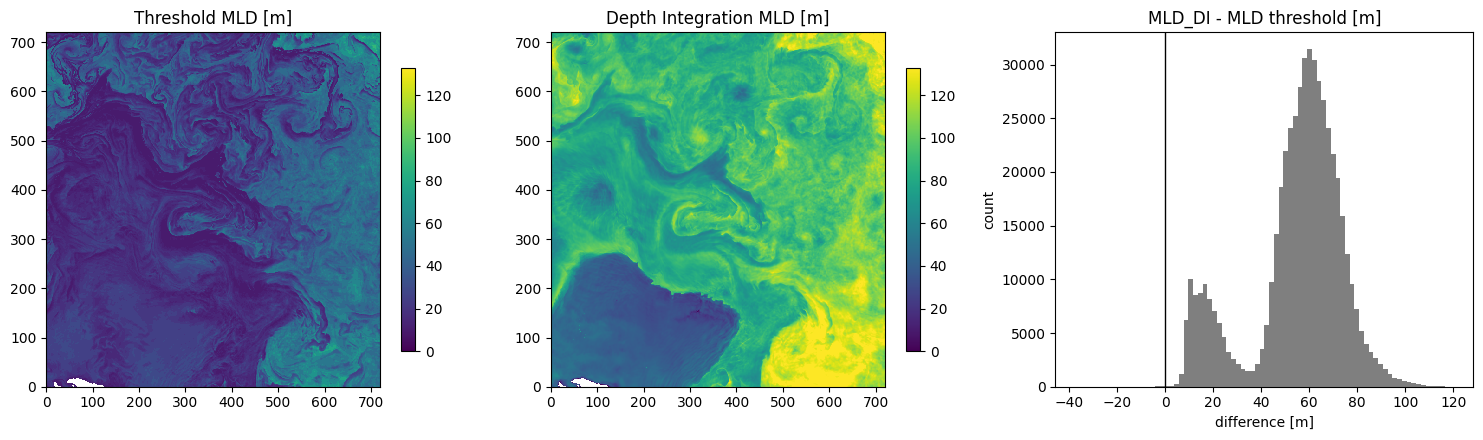

median difference (DI - threshold): 58.6 m


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

vmax = float(np.nanpercentile(np.concatenate(
    [mld_thr.values.ravel(), mld_di.values.ravel()]), 99))

im0 = axes[0].pcolormesh(mld_thr.values, vmin=0, vmax=vmax, cmap='viridis')
axes[0].set_title('Threshold MLD [m]')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].pcolormesh(mld_di.values, vmin=0, vmax=vmax, cmap='viridis')
axes[1].set_title('Depth Integration MLD [m]')
fig.colorbar(im1, ax=axes[1], shrink=0.8)

diff = (mld_di - mld_thr).values.ravel()
diff = diff[np.isfinite(diff)]
axes[2].hist(diff, bins=80, color='tab:gray')
axes[2].axvline(0, color='k', lw=1)
axes[2].set_title('MLD_DI - MLD threshold [m]')
axes[2].set_xlabel('difference [m]')
axes[2].set_ylabel('count')

fig.tight_layout()
plt.show()

print('median difference (DI - threshold): %.1f m' % float(np.median(diff)))

## Takeaways

- The **threshold** estimator snaps to a discrete model level and responds to
  the depth where density first departs from its near-surface value.
- The **Depth Integration** estimator is a continuous, $N^2$-weighted depth: it
  is pulled toward whatever depth carries the strongest stratification within
  the upper 300 m, so it can differ systematically from the threshold value,
  especially under deep or smeared pycnoclines.

*Generated by JXP and Claude*